In [1]:
import scipy.ndimage.measurements
import numpy as np
import os
import pandas
import logging
import psutil
logging.basicConfig(filename='LogVoidAnalysis.log', level=logging.DEBUG)
import h5py
import requests
import matplotlib.pyplot as plt
import numpy as np
import time

In [2]:
key = "api_key.txt"

with open(key) as file :
    api_key = file.read()


In [3]:
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":f"{api_key}"}

def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically
    
    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename # return the filename string
    
    return r

In [4]:
data = np.load("tng300-1_z0_positions.npz")
pos = np.column_stack([data["x_pos"], data["y_pos"], data["z_pos"]])
print("loaded", len(pos), "subhalos")

loaded 14485709 subhalos


In [5]:
def find_clumps(blobs):
    """
    Keyword Arguments:
    blobs -- Array of True / False entries to find clumps
    """

    la, nf = scipy.ndimage.measurements.label(blobs)
    logging.info("Found %d clumps.",  nf)

    return la, nf

In [6]:
def _asel(a,ia,pad):
    ia = np.array(ia, dtype = int)
    # TODO: be smarter about boundaries...
    js = np.clip(ia[:,0]-pad,0,a.shape)
    je = np.clip(ia[:,1]+pad,0,a.shape)
    # return a[(ia[0][0]-pad):(ia[0][1]+pad),(ia[1][0]-pad):(ia[1][1]+pad),(ia[2][0]-pad):(ia[2][1]+pad)]
    return a[js[0]:je[0],js[1]:je[1],js[2]:je[2]]

In [7]:
def _analyze_clump(cid, la, g, comi, size, tempthresh_hot, mode, thresh_unit = None, padding_hot = 2, mincells_hot = 16):
    """
    Keyword Arguments:
    cid -- Clump id
    la  -- array of clump IDs
    g   -- yt grid
    comi -- Center of mass in index units
    padding_hot  -- (default 2)
    mincells_hot -- (default 16)
    """
    assert 'temp' in mode, "mode `%s` not supported yet." %(mode)

    cdat = {'cid' : cid, 'isize' : size,
            'ix' : comi[0], 'iy' : comi[1], 'iz' : comi[2] }
    #ia = [int(i) for i in np.round(np.array(comi))]

    ia = []
    for i in range(3):
        ii = np.arange(la.shape[i])
        myax = tuple([ j for j in range(3) if i != j ])
        cm = np.any(la == cid, axis = myax)
        ia.append([ii[cm][0], ii[cm][-1]])

    #pad = int(np.round(0.5 * size**(1/3.))) + padding_hot
    pad = padding_hot
    while True:
        if thresh_unit is None:
            cgrid = g[mode].value
        else:
            cgrid = g[mode].to(thresh_unit).value
        mhot = _asel(cgrid,ia,pad) > tempthresh_hot
        if np.sum(mhot) > mincells_hot:
            break
        pad += 1

    mclump = _asel(la,ia,pad) == cid
    assert np.sum(mclump) == size, "%d versus %d (is = %s)" %(np.sum(mclump), size, str(ia))

    cdat['ipad'] = pad

    for ck in [mode, 'density', 'velocity_x', 'velocity_y', 'velocity_z']:
        for cm, clbl in [(mhot, 'hot'), (mclump, 'clump')]:
            cdat[ck + '_' + clbl] = float(np.mean(_asel(g[ck],ia,pad)[cm]).value)
        if psutil.virtual_memory().percent > 93.0:
            logging.warning("Clearing memory.")
            g.clear_data() # to free some memory-->can't do that as will be used for other clumps

    return cdat

In [8]:
def clump_analysis(ds, threshold = None, thresh_hot = None, thresh_unit = None,outdir = None, mode = 'temperature', minsize = 16,clumps_to_particles = False,**kwargs):
    """
    Keyword Arguments:
    ds           -- yt data set
    threshold    -- Threshold in code units.
    mode         -- (default 'temp')
    minsize      -- (default 16)
    clumps_to_particles -- If `True` will also return DF in which particle ID &
                            corresponding blob ID is listed
    """
    assert threshold is not None
    assert thresh_hot is not None

    logging.info("Analyze clumps for %s.", str(ds))
    LEVEL = 5-1 # since FLASH/FORTRAN is 1-based whereas python is 1-based
    g = ds.covering_grid(level=LEVEL, left_edge=ds.domain_left_edge,
                        dims=ds.domain_dimensions*2**LEVEL)
    if thresh_unit is None:
        dat = g[mode].value
    else:
        dat = g[mode].to(thresh_unit).value

    if mode == 'temp' or mode == 'temperature':
        blobs = dat < threshold
    else:
        blobs = dat > threshold

    la, nf = find_clumps(blobs)

    # Find sizes
    ids, sizes = np.unique(la, return_counts=True)
    print("num clumps: ", len(ids))
    return len(ids)

    logging.info("Found %d clumps above minimum size of %d cells.", np.sum(sizes > minsize) - 1, minsize)
    ids   = ids[sizes >= minsize][1:]
    sizes = sizes[sizes >= minsize][1:]
    if len(ids) == 0:
        logging.error("No clumps found!")
        return
    print("num big clumps: ", len(ids))

    # Compute clump positions in code units
    logging.info("Computing clump positions.")
    comi = np.array(scipy.ndimage.measurements.center_of_mass(blobs,la,ids))

    # For particles
    if clumps_to_particles:
        logging.info("Computing clumps for particles...")
        df_particles = _compute_clumps_to_particles(ds, la)
        ofn_particles = os.path.join(outdir, str(ds)) + "_particles.hdf5"

    logging.info("Analyze clumps...")
    clumpdat = []
    for i,cid in enumerate(ids):
        clumpdat.append(_analyze_clump(cid, la, g, comi[i], sizes[i], thresh_hot, mode, thresh_unit = thresh_unit))
    g.clear_data() # Try to free some memory

    df = pandas.DataFrame(clumpdat).set_index('cid')

    # Convert some quantities to code units
    for i,k in enumerate('xyz'):
        df[k] = ((df['i' + k] / np.array(blobs.shape)[i]) * ds.domain_width[i] + ds.domain_left_edge[i])
    Vcell = np.product(ds.domain_width / ds.domain_dimensions)
    df['size'] = df['isize'] * Vcell

    if outdir is not None:
        logging.info("Writing to %s", ofn)
        df.to_hdf(ofn,'dat')
        if clumps_to_particles:
            df_particles.to_hdf(ofn_particles,'dat')
    else:
        if clumps_to_particles:
            return df, df_particles
        else:
            return df

In [18]:
from PIL import Image
with Image.open("tng300-1 slice galaxy plot.png") as im:
    data = im.getdata()

print(data)

In [19]:
data.getpixel((0,0))

(255, 255, 255, 255)

In [20]:
voids = np.zeros((int(1e3), int(1e3)))
for i in range(int(1e3)):
    for j in range(int(1e3)):
        try:
            rgb = data.getpixel((i,j))
            if rgb[0] > 235 and rgb[1] > 235 and rgb[2] > 235:
                voids[i,j] = True
            else:
                voids[i,j] = False
        except:
            break
#voids = voids[voids != -1]
voids.shape

(1000, 1000)

In [21]:
len(voids[voids == True])

359841

In [22]:
la, nf = scipy.ndimage.measurements.label(voids)

C:\Users\mika2\AppData\Local\Temp\ipykernel_27268\3357307679.py:1: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  la, nf = scipy.ndimage.measurements.label(voids)


In [23]:
la

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1000, 1000), dtype=int32)

In [24]:
nf

5371

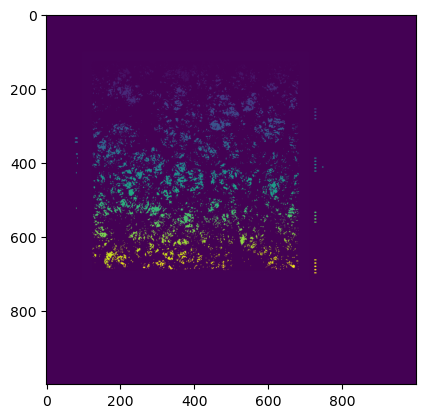

In [25]:
plt.imshow(la)